<div style="
border-left:6px solid #2a6fdb;
background-color:#f5f7fa;
padding:15px;
font-size:32px;
font-weight:600;
">
Métaheuristiques pour le problème du voyageur de commerce (TSP)
</div>

<p style="margin-top:10px;font-size:18px;text-align:right">
Réalisé par : <b>Amal Aabour</b>
</p>
<p style="margin-top:10px;font-size:18px;text-align:right">
Encadré par : <b>Dr. Mustapha OUDANI</b>
</p>

<div style="background-color:#f5f5f5;padding:15px;border-radius:10px;border-left:6px solid #2c7be5">

<h2 style="margin-top:0">Partie 3 – Grandes instances</h2>

<b>Instances étudiées :</b> 
<code>rat575</code>, 
<code>lin318</code>, 
<code>pr439</code>, 
<code>pcb442</code>

</div>

<div style="margin-left:20px;padding:10px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Lecture et affichage des données</h3>

</div>

In [2]:
# Import des bibliothèques
import os
import tsplib95
import pandas as pd
from IPython.display import display, HTML

# Dossier contenant les petites instances
folder = "large_instances"

# Liste des petites instances
large_instances = ["lin318" ,"pr439", "pcb442", "rat575"]


# Lecture et affichage des données
for name in large_instances:
    # chemin du fichier
    file_path = os.path.join(folder, f"{name}.tsp")

    # charger instance
    problem = tsplib95.load(file_path)

    # En-tête visuel
    html = f"""
    <div style="border-left:6px solid #2c7be5;padding:10px;background:#f8f9fa;margin-top:10px">
    <h3>Instance : {problem.name}</h3>
    <b>Chemin :</b> {file_path}<br>
    <b>Nombre de villes :</b> {problem.dimension}<br>
    <b>Type de distance :</b> {problem.edge_weight_type}
    </div>
    """
    display(HTML(html))

    # coordonnées
    coords = problem.node_coords

    # transformer en DataFrame
    df = pd.DataFrame.from_dict(coords, orient="index", columns=["X", "Y"])
    df.index.name = "Ville"
    df = df.reset_index()

    # afficher seulement les 5 premières villes
    display(df.head())

,Ville,X,Y
0,1,63,71
1,2,94,71
2,3,142,370
3,4,173,1276
4,5,205,1213


,Ville,X,Y
0,1,7125,11300
1,2,7225,11050
2,3,7225,11150
3,4,7375,11300
4,5,7500,11200


,Ville,X,Y
0,1,200.0,400.0
1,2,200.0,500.0
2,3,200.0,600.0
3,4,200.0,700.0
4,5,200.0,800.0


,Ville,X,Y
0,1,6,18
1,2,11,0
2,3,24,6
3,4,36,13
4,5,41,19


<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Visualisation des coordonnées géographiques des instances TSP</h3>

<p><b>Objectif :</b> représenter graphiquement les villes afin d’observer leur répartition spatiale.</p>

<p><b>Analyse :</b> certaines instances présentent une distribution relativement homogène des villes,
tandis que d’autres révèlent la présence de zones fortement concentrées ou de villes isolées.</p>

<p><b>Impact :</b> la structure géographique des instances influence directement la difficulté du problème
et peut affecter la qualité des solutions obtenues par les heuristiques et les métaheuristiques.</p>

</div>

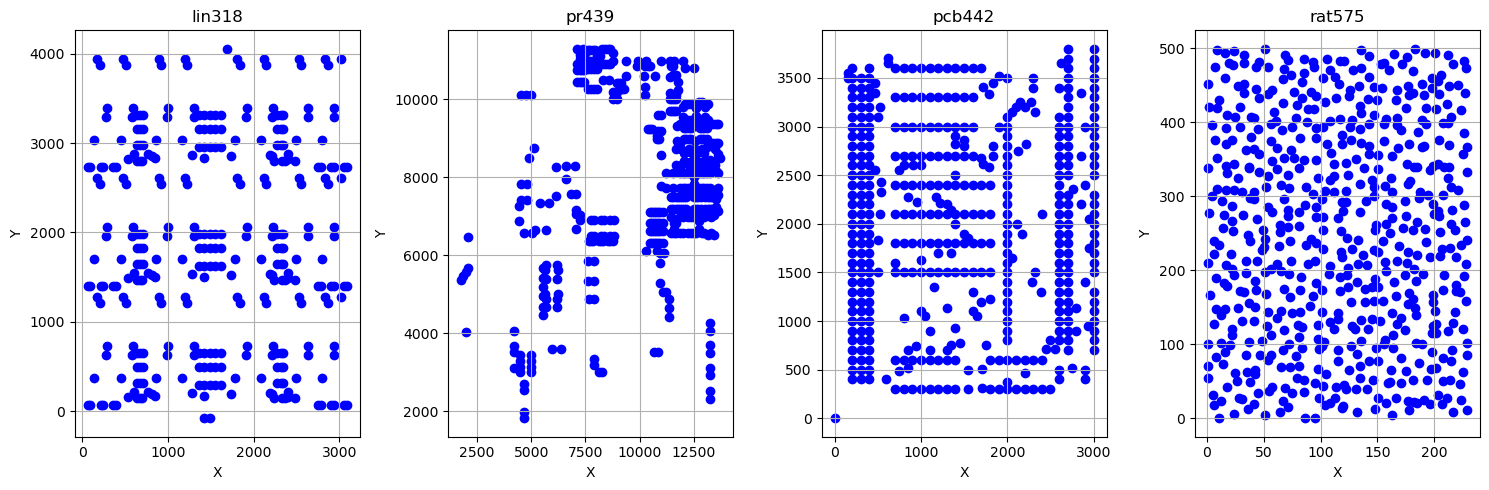

In [10]:
import matplotlib.pyplot as plt
import os
import tsplib95

folder = "large_instances"

large_instances =  ["lin318" ,"pr439", "pcb442", "rat575"]



# créer une figure avec 3 sous-graphes
fig, axes = plt.subplots(1, 4, figsize=(15,5))

for i, name in enumerate(large_instances):

    path = os.path.join(folder, f"{name}.tsp")
    problem = tsplib95.load(path)
    coords = dict(problem.node_coords)

    x = [coords[j][0] for j in coords]
    y = [coords[j][1] for j in coords]

    axes[i].scatter(x, y, color="blue")
    axes[i].set_title(name)
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

<div style="margin-left:20px;padding:10px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Construction des matrices de distance</h3>

</div>

In [12]:
import os
import math
import tsplib95
import pandas as pd
from IPython.display import display, HTML

# dossier des petites instances
folder = "large_instances"

large_instances =  ["lin318" ,"pr439", "pcb442", "rat575"]


distance_matrices = {}

for name in large_instances:

    # 1) Charger les données
    path = os.path.join(folder, f"{name}.tsp")
    problem = tsplib95.load(path)
    coords = dict(problem.node_coords)

    # 2) Préparer indexation
    cities = sorted(coords.keys())
    n = len(cities)
    index = {city: i for i, city in enumerate(cities)}

    # 3) Construire matrice des distances
    dist = [[0.0]*n for _ in range(n)]

    for i in range(n):
        xi, yi = coords[cities[i]]
        for j in range(i+1, n):
            xj, yj = coords[cities[j]]
            d = math.sqrt((xi-xj)**2 + (yi-yj)**2)
            dist[i][j] = d
            dist[j][i] = d

    # 4) Stocker
    distance_matrices[name] = {
        "cities": cities,
        "index": index,
        "dist": dist
    }

    # -------- Affichage propre -------- #

    # entête visuel
    html = f"""
    <div style="border-left:6px solid #2c7be5;background:#f8f9fa;padding:12px;margin-top:15px;border-radius:6px">
    <h3 style="margin-top:0">Instance : {name}</h3>
    <b>Fichier :</b> {path}<br>
    <b>Nombre de villes :</b> {n}<br>
    <b>Type de distance :</b> {problem.edge_weight_type}
    </div>
    """
    display(HTML(html))

    # vérifier que ville 1 existe
    if 1 not in index:
        display(HTML("<b>Ville 1 n'existe pas dans cette instance</b>"))
        continue

    i = index[1]

    # créer tableau pandas
    data = []

    for city in cities:
        j = index[city]
        d = dist[i][j]
        data.append({
            "Ville départ": 1,
            "Ville destination": city,
            "Distance": round(d,2)
        })

    df = pd.DataFrame(data)

    display(df)

# résumé final
display(HTML(f"<b>Matrices construites pour :</b> {list(distance_matrices.keys())}"))

,Ville départ,Ville destination,Distance
0,1,1,0.00
1,1,2,31.00
2,1,3,309.26
3,1,4,1210.01
4,1,5,1150.79
...,...,...,...
313,1,314,3159.42
314,1,315,3422.81
315,1,316,1362.28
316,1,317,1440.83


,Ville départ,Ville destination,Distance
0,1,1,0.00
1,1,2,269.26
2,1,3,180.28
3,1,4,250.00
4,1,5,388.10
...,...,...,...
434,1,435,7559.31
435,1,436,7700.53
436,1,437,7841.76
437,1,438,7982.99


,Ville départ,Ville destination,Distance
0,1,1,0.00
1,1,2,100.00
2,1,3,200.00
3,1,4,300.00
4,1,5,400.00
...,...,...,...
437,1,438,3472.30
438,1,439,1731.73
439,1,440,2370.36
440,1,441,557.31


,Ville départ,Ville destination,Distance
0,1,1,0.00
1,1,2,18.68
2,1,3,21.63
3,1,4,30.41
4,1,5,35.01
...,...,...,...
570,1,571,512.53
571,1,572,510.12
572,1,573,514.39
573,1,574,515.91


In [16]:
import pandas as pd
from IPython.display import display, HTML

for name in large_instances:

    cities = distance_matrices[name]["cities"]
    dist = distance_matrices[name]["dist"]

    display(HTML(f"<h3>Matrice des distances — Instance : {name}</h3>"))

    df_matrix = pd.DataFrame(dist, index=cities, columns=cities)
    display(df_matrix)

,1,2,3,4,5,6,7,8,9,10,...,309,310,311,312,313,314,315,316,317,318
1,0.000000,31.000000,309.260408,1210.010331,1150.794508,150.013333,181.011049,598.205650,696.649840,299.006689,...,4398.664911,4865.583007,4003.456507,4027.427963,2862.965246,3159.418459,3422.807327,1362.283377,1440.829275,4304.550615
2,31.000000,0.000000,302.828334,1207.586850,1147.381802,119.016806,150.013333,587.881791,687.489636,268.007463,...,4378.416380,4846.831233,3980.341819,4004.203916,2857.247802,3148.739748,3407.362176,1331.476248,1410.001418,4292.907756
3,309.260408,302.828334,0.000000,906.530198,845.350815,309.260408,317.812838,292.499573,388.490669,372.828379,...,4123.273578,4581.539043,3749.651984,3774.565670,2554.494079,2851.801711,3125.586025,1351.749237,1426.505170,3998.102800
4,1210.010331,1207.586850,906.530198,0.000000,70.661163,1207.662618,1209.086432,654.159766,555.009910,1221.707821,...,3488.539522,3894.726306,3228.459230,3257.057107,1663.347528,2016.829195,2380.332960,1839.445840,1893.767145,3167.529163
5,1150.794508,1147.381802,845.350815,70.661163,0.000000,1144.027972,1144.664580,587.307415,487.283285,1154.722910,...,3502.050971,3915.015453,3229.059306,3257.337563,1716.497014,2056.784140,2406.114295,1771.498800,1826.456953,3207.975686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,3159.418459,3148.739748,2851.801711,2016.829195,2056.784140,3112.181389,3102.839023,2561.235054,2463.315652,3069.882408,...,1816.437172,2060.834054,1913.818434,1945.426688,578.775431,0.000000,615.000000,3121.189677,3128.559093,1151.222394
315,3422.807327,3407.362176,3125.586025,2380.332960,2406.114295,3351.843970,3337.463857,2834.011291,2744.268391,3284.827697,...,1219.946310,1532.492088,1310.048091,1341.212138,1183.543831,615.000000,0.000000,3132.106320,3123.936139,1026.692749
316,1362.283377,1331.476248,1351.749237,1839.445840,1771.498800,1213.062241,1182.299877,1343.339868,1394.158169,1065.330465,...,3794.273712,4323.550624,3252.559607,3268.791826,3070.055700,3121.189677,3132.106320,0.000000,79.000000,4143.203109
317,1440.829275,1410.001418,1426.505170,1893.767145,1826.456953,1291.508033,1260.717256,1411.056696,1459.140158,1143.617069,...,3763.154262,4294.960885,3213.499806,3229.145553,3091.863677,3128.559093,3123.936139,79.000000,0.000000,4138.691218


,1,2,3,4,5,6,7,8,9,10,...,430,431,432,433,434,435,436,437,438,439
1,0.000000,269.258240,180.277564,250.000000,388.104367,500.624610,600.520607,700.446286,800.390530,928.035560,...,9086.528490,10851.756770,9786.629910,9641.479399,8913.367770,7559.307177,7700.527579,7841.755224,7982.989728,6984.491750
2,269.258240,0.000000,100.000000,291.547595,313.249102,458.938994,548.292805,640.800281,735.272058,843.356390,...,8874.260533,10588.938804,9570.952147,9426.458773,8770.012828,7443.999261,7585.388916,7726.779730,7868.171643,6888.622867
3,180.277564,100.000000,0.000000,212.132034,279.508497,419.076365,515.388203,612.882534,711.073133,828.402076,...,8970.089186,10671.486541,9667.374256,9522.768768,8850.317791,7516.523465,7657.879929,7799.238745,7940.599788,6955.438520
4,250.000000,291.547595,212.132034,0.000000,160.078106,251.246891,350.891721,450.693909,550.567889,679.153885,...,9157.101070,10713.221971,9852.188843,9708.018593,9060.111754,7728.559051,7869.918996,8011.281109,8152.645276,7167.330396
5,388.104367,313.249102,279.508497,160.078106,0.000000,145.773797,237.170825,333.541602,431.566913,550.567889,...,9099.622245,10561.309104,9791.386521,9647.862458,9055.730230,7743.142127,7884.557692,8025.973461,8167.389424,7194.181677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,7559.307177,7443.999261,7516.523465,7728.559051,7743.142127,7884.319882,7955.029855,8026.362813,8098.302291,8154.944819,...,4065.172198,11642.379482,4645.696934,4522.167622,1653.027525,0.000000,141.421356,282.842712,424.264069,800.000000
436,7700.527579,7585.388916,7657.879929,7869.918996,7884.557692,8025.739841,8096.449839,8167.772034,8239.690528,8296.271753,...,4054.704058,11710.038429,4620.876540,4500.000000,1550.000000,141.421356,0.000000,141.421356,282.842712,905.538514
437,7841.755224,7726.779730,7799.238745,8011.281109,8025.973461,8167.159849,8237.869870,8309.181668,8381.079883,8437.601851,...,4049.151146,11779.006749,4600.271731,4482.186966,1453.444185,282.842712,141.421356,0.000000,141.421356,1019.803903
438,7982.989728,7868.171643,7940.599788,8152.645276,8167.389424,8308.579903,8379.289946,8450.591695,8522.470299,8578.934957,...,4048.533685,11849.261580,4583.939354,4468.780594,1364.734406,424.264069,282.842712,141.421356,0.000000,1140.175425


,1,2,3,4,5,6,7,8,9,10,...,433,434,435,436,437,438,439,440,441,442
1,0.000000,100.000000,200.000000,300.000000,400.000000,500.000000,600.000000,700.000000,800.000000,900.000000,...,2784.851881,3063.494736,3207.023542,2818.226393,3744.329045,3472.304710,1731.733236,2370.358623,557.314992,447.213595
2,100.000000,0.000000,100.000000,200.000000,300.000000,400.000000,500.000000,600.000000,700.000000,800.000000,...,2766.839352,3020.761493,3156.738824,2718.896835,3661.966685,3393.655846,1633.676835,2359.364321,550.090902,538.516481
3,200.000000,100.000000,0.000000,100.000000,200.000000,300.000000,400.000000,500.000000,600.000000,700.000000,...,2752.344455,2980.771712,3108.858311,2619.618293,3580.502758,3316.157415,1535.871088,2352.573059,560.892146,632.455532
4,300.000000,200.000000,100.000000,0.000000,100.000000,200.000000,300.000000,400.000000,500.000000,600.000000,...,2741.422988,2943.637206,3063.494736,2520.396794,3500.000000,3239.891974,1438.367130,2350.021276,588.727441,728.010989
5,400.000000,300.000000,200.000000,100.000000,0.000000,100.000000,200.000000,300.000000,400.000000,500.000000,...,2734.117774,2909.467305,3020.761493,2421.239352,3420.526275,3164.948657,1341.230778,2351.722773,631.347765,824.621125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,3472.304710,3393.655846,3316.157415,3239.891974,3164.948657,3091.423620,3019.420474,2949.050695,2880.433995,2813.698633,...,2283.002409,1535.219854,1267.635594,1800.694311,350.570963,0.000000,2075.234926,2450.816191,3088.769982,3912.147748
439,1731.733236,1633.676835,1535.871088,1438.367130,1341.230778,1244.548111,1148.433716,1053.043209,958.592719,865.390085,...,2661.296676,2445.178930,2420.516474,1100.045454,2256.745444,2075.234926,0.000000,2452.039967,1624.961538,2165.848563
440,2370.358623,2359.364321,2352.573059,2350.021276,2351.722773,2357.668340,2367.826007,2382.141893,2400.541606,2422.932108,...,449.444101,1114.271062,1398.427689,3212.631320,2801.178323,2450.816191,2452.039967,0.000000,1813.394607,2646.998300
441,557.314992,550.090902,560.892146,588.727441,631.347765,686.002915,750.066664,821.340368,898.109125,979.081202,...,2228.003591,2535.271189,2696.961253,2719.742635,3385.646172,3088.769982,1624.961538,1813.394607,0.000000,895.879456


,1,2,3,4,5,6,7,8,9,10,...,566,567,568,569,570,571,572,573,574,575
1,0.000000,18.681542,21.633308,30.413813,35.014283,46.840154,58.694122,65.069194,81.786307,90.609050,...,496.327513,490.520132,485.740672,499.956998,499.799960,512.532926,510.118614,514.393818,515.911814,513.513388
2,18.681542,0.000000,14.317821,28.178006,35.510562,40.311289,53.758720,61.846584,75.006666,84.005952,...,512.478292,506.502715,501.422975,515.538553,515.139787,527.811519,525.176161,529.278755,530.548772,527.777415
3,21.633308,14.317821,0.000000,13.892444,21.400935,27.018512,40.112342,47.853944,62.201286,71.175839,...,503.611954,497.443464,492.036584,506.040512,505.398852,518.005791,515.163081,519.107889,520.162475,517.088000
4,30.413813,28.178006,13.892444,0.000000,7.810250,17.000000,28.284271,35.057096,51.419841,60.207973,...,494.222622,487.878059,482.171131,496.066528,495.201979,507.745015,504.713780,508.513520,509.372163,506.024703
5,35.014283,35.510562,21.400935,7.810250,0.000000,17.204651,25.079872,30.265492,48.466483,56.920998,...,487.348951,480.940745,475.127351,488.983640,488.043031,500.563682,497.470602,501.223503,502.020916,498.592018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,512.532926,527.811519,518.005791,507.745015,500.563682,511.331595,504.242997,496.789694,507.358847,505.715335,...,47.042534,41.231056,33.015148,19.313208,13.038405,0.000000,10.816654,18.681542,30.083218,46.238512
572,510.118614,525.176161,515.163081,504.713780,497.470602,507.961613,500.639591,493.077073,503.289181,501.470837,...,56.142675,49.162994,38.275318,27.018512,16.763055,10.816654,0.000000,9.055385,20.099751,35.735137
573,514.393818,529.278755,519.107889,508.513520,501.223503,511.489003,503.978174,496.327513,506.235123,504.266794,...,65.069194,58.215118,47.127487,36.055513,25.709920,18.681542,9.055385,0.000000,11.401754,27.730849
574,515.911814,530.548772,520.162475,509.372163,502.020916,511.973632,504.210274,496.444357,505.940708,503.774751,...,76.236474,69.028979,57.070132,47.010637,36.124784,30.083218,20.099751,11.401754,0.000000,16.643317


<div style="margin-left:20px;padding:10px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">
Heuristique du plus proche voisin : construction de la tournée
</h3>

<p style="margin-bottom:0"><b>Ville de départ :</b> 1</p>

</div>

In [20]:
import time

def nearest_neighbor_with_matrix(cities, idx, dist, start_city=1):
    t0 = time.time()

    n = len(cities)
    visited = set([start_city])
    tour = [start_city]
    current = start_city

    while len(visited) < n:
        i = idx[current]
        best_city = None
        best_d = float("inf")

        for city in cities:
            if city not in visited:
                d = dist[i][idx[city]]
                if d < best_d:
                    best_d = d
                    best_city = city

        tour.append(best_city)
        visited.add(best_city)
        current = best_city

    tour.append(start_city)  # fermeture

    cost = 0.0
    for k in range(len(tour) - 1):
        cost += dist[idx[tour[k]]][idx[tour[k + 1]]]

    exec_time = time.time() - t0
    return tour, cost, exec_time


print("\n==============================")
print("NN sur les petites instances")
print("==============================")

for name in large_instances:
    cities = distance_matrices[name]["cities"]
    idx = distance_matrices[name]["index"]
    dist = distance_matrices[name]["dist"]

    tour, cost, t = nearest_neighbor_with_matrix(cities, idx, dist)

    print(f"\nInstance : {name}")
    print("Tournée complète :")
    print(tour)  #  affiche toute la tournée
    print(f"Coût NN = {cost:.2f}")
    print(f"Temps NN = {t:.4f} s")



NN sur les petites instances

Instance : lin318
Tournée complète :
[1, 2, 6, 7, 10, 11, 15, 103, 21, 22, 29, 30, 31, 32, 28, 23, 20, 19, 24, 27, 26, 25, 18, 16, 17, 9, 8, 3, 12, 33, 36, 37, 42, 43, 46, 52, 53, 58, 57, 54, 51, 47, 44, 41, 104, 40, 45, 48, 50, 55, 56, 59, 105, 62, 63, 70, 74, 75, 81, 69, 73, 76, 80, 79, 77, 72, 68, 67, 71, 78, 82, 83, 84, 85, 86, 89, 90, 99, 98, 93, 92, 91, 96, 97, 101, 102, 64, 49, 316, 317, 39, 38, 145, 150, 153, 155, 160, 161, 164, 210, 162, 159, 156, 152, 149, 146, 148, 151, 157, 158, 163, 167, 168, 175, 179, 180, 186, 174, 178, 181, 185, 184, 182, 177, 173, 172, 176, 183, 187, 188, 189, 190, 87, 88, 196, 197, 201, 202, 206, 207, 100, 95, 94, 198, 203, 204, 195, 194, 191, 169, 65, 66, 61, 60, 154, 209, 138, 133, 128, 125, 208, 126, 127, 134, 135, 136, 137, 34, 35, 14, 13, 116, 115, 112, 111, 107, 106, 4, 5, 120, 117, 124, 129, 132, 131, 130, 123, 121, 122, 114, 113, 108, 110, 109, 216, 217, 220, 221, 118, 119, 225, 313, 231, 232, 239, 240, 241, 242,

In [22]:
import time
import pandas as pd
from IPython.display import display, HTML


def nearest_neighbor_with_matrix(cities, idx, dist, start_city=1):
    t0 = time.time()

    n = len(cities)
    visited = set([start_city])
    tour = [start_city]
    current = start_city

    while len(visited) < n:
        i = idx[current]
        best_city = None
        best_d = float("inf")

        for city in cities:
            if city not in visited:
                d = dist[i][idx[city]]
                if d < best_d:
                    best_d = d
                    best_city = city

        tour.append(best_city)
        visited.add(best_city)
        current = best_city

    tour.append(start_city)

    cost = 0.0
    for k in range(len(tour) - 1):
        cost += dist[idx[tour[k]]][idx[tour[k + 1]]]

    exec_time = time.time() - t0
    return tour, cost, exec_time


display(HTML("<h2>Heuristique du plus proche voisin (NN) – Petites instances</h2>"))

results = []

for name in large_instances:

    cities = distance_matrices[name]["cities"]
    idx = distance_matrices[name]["index"]
    dist = distance_matrices[name]["dist"]

    tour, cost, t = nearest_neighbor_with_matrix(cities, idx, dist)

    # entête visuel
    display(HTML(f"""
    <div style="border-left:6px solid #2c7be5;background:#f8f9fa;padding:10px;margin-top:15px">
    <h3>Instance : {name}</h3>
    </div>
    """))

    path_str = " → ".join(map(str, tour))
    display(HTML(f"<b>Tournée obtenue :</b><br>{path_str}"))

    # stocker résultats
    results.append({
        "Instance": name,
        "Coût NN": round(cost,2),
        "Temps (s)": round(t,4)
    })


# tableau final des performances
df_results = pd.DataFrame(results)

display(HTML("<h3>Résumé des performances NN</h3>"))
display(df_results)

,Instance,Coût NN,Temps (s)
0,lin318,54033.58,0.0010
1,pr439,131282.09,0.0132
2,pcb442,61984.05,0.0092
3,rat575,8449.32,0.0799


<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Test : variation de la ville de départ</h3>

<p><b>Principe :</b> pour les petites instances, toutes les villes sont utilisées comme point de départ afin d'évaluer l'influence du choix initial.</p>

<b>Instances testées :</b>

- <code>eil51</code> → 51 villes → 51 départs possibles  
- <code>berlin52</code> → 52 villes → 52 départs possibles  
- <code>st70</code> → 70 villes → 70 départs possibles  

</div>

In [24]:
import pandas as pd
from IPython.display import display, HTML

display(HTML("<h2>NN multi-start : meilleure solution par instance</h2>"))

results = {}
summary = []

for name in distance_matrices.keys():

    cities = distance_matrices[name]["cities"]
    idx = distance_matrices[name]["index"]
    dist = distance_matrices[name]["dist"]

    best_cost = float("inf")
    best_tour = None
    best_start = None
    all_costs = []

    # tester toutes les villes de départ
    for start in cities:
        tour, cost, t = nearest_neighbor_with_matrix(cities, idx, dist, start_city=start)
        all_costs.append(cost)

        if cost < best_cost:
            best_cost = cost
            best_tour = tour
            best_start = start

    avg_cost = sum(all_costs)/len(all_costs)
    worst_cost = max(all_costs)

    results[name] = {
        "best_cost": best_cost,
        "best_tour": best_tour,
        "best_start": best_start,
        "avg_cost": avg_cost,
        "worst_cost": worst_cost
    }

    # affichage propre par instance
    display(HTML(f"""
    <div style="border-left:6px solid #2c7be5;background:#f8f9fa;padding:10px;margin-top:15px">
    <h3>Instance : {name}</h3>
    </div>
    """))

    df = pd.DataFrame({
        "Meilleure ville départ":[best_start],
        "Meilleur coût NN":[round(best_cost,2)],
        "Coût moyen":[round(avg_cost,2)],
        "Pire coût":[round(worst_cost,2)]
    })

    display(df)

    # résumé global
    summary.append({
        "Instance": name,
        "Best NN": round(best_cost,2),
        "Start": best_start
    })

# tableau final
display(HTML("<h2>Résumé final</h2>"))

df_summary = pd.DataFrame(summary)
display(df_summary)

,Meilleure ville départ,Meilleur coût NN,Coût moyen,Pire coût
0,194,49215.61,52599.16,58862.76


,Meilleure ville départ,Meilleur coût NN,Coût moyen,Pire coût
0,365,127228.36,135690.65,146287.29


,Meilleure ville départ,Meilleur coût NN,Coût moyen,Pire coût
0,396,58952.97,62226.06,66163.73


,Meilleure ville départ,Meilleur coût NN,Coût moyen,Pire coût
0,256,7972.33,8297.69,8690.26


,Instance,Best NN,Start
0,lin318,49215.61,194
1,pr439,127228.36,365
2,pcb442,58952.97,396
3,rat575,7972.33,256


<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Test de robustesse : départ aléatoire répété</h3>

<p><b>Principe :</b> l’heuristique du plus proche voisin (NN) est exécutée <b>30 fois</b> avec des villes de départ choisies aléatoirement afin d’évaluer la stabilité des solutions obtenues.</p>

<p><b>Nombre d'exécutions :</b> 30</p>

</div>

In [26]:
from IPython.display import display, HTML
import random
import statistics

display(HTML("<h3>Test de robustesse : départ aléatoire répété (30 exécutions NN)</h3>"))

R = 30
random.seed(0)

robust_results = {}

for name in distance_matrices.keys():

    display(HTML(f"""
    <div style="border-left:6px solid #2c7be5;background:#f8f9fa;padding:10px;margin-top:10px">
    <b>Instance :</b> {name}
    </div>
    """))

    cities = distance_matrices[name]["cities"]
    idx = distance_matrices[name]["index"]
    dist = distance_matrices[name]["dist"]

    costs = []
    starts = []

    best_cost = float("inf")
    best_tour = None
    best_start = None

    for r in range(R):

        start = random.choice(cities)

        tour, cost, t = nearest_neighbor_with_matrix(
            cities, idx, dist, start_city=start
        )

        costs.append(cost)
        starts.append(start)

        if cost < best_cost:
            best_cost = cost
            best_tour = tour
            best_start = start

    avg_cost = statistics.mean(costs)
    worst_cost = max(costs)
    std_dev = statistics.pstdev(costs)

    robust_results[name] = {
        "best_cost": best_cost,
        "avg_cost": avg_cost,
        "worst_cost": worst_cost,
        "std_dev": std_dev,
        "best_start": best_start,
        "best_tour": best_tour,
        "all_costs": costs
    }

    print(f"Meilleur coût : {best_cost:.2f} (start = {best_start})")
    print(f"Coût moyen : {avg_cost:.2f}")
    print(f"Pire coût : {worst_cost:.2f}")
    print(f"Écart-type : {std_dev:.2f}")

print("\nRésumé final")
print("--------------------------------")

for name in robust_results:
    print(
        f"{name} → best={robust_results[name]['best_cost']:.2f} "
        f"avg={robust_results[name]['avg_cost']:.2f}"
    )

Meilleur coût : 50455.84 (start = 273)
Coût moyen : 52595.13
Pire coût : 54856.45
Écart-type : 1023.00


Meilleur coût : 127803.36 (start = 364)
Coût moyen : 134772.83
Pire coût : 144017.11
Écart-type : 2966.57


Meilleur coût : 60416.27 (start = 309)
Coût moyen : 62565.23
Pire coût : 65044.91
Écart-type : 1140.12


Meilleur coût : 8089.63 (start = 189)
Coût moyen : 8289.74
Pire coût : 8660.46
Écart-type : 133.94

Résumé final
--------------------------------
lin318 → best=50455.84 avg=52595.13
pr439 → best=127803.36 avg=134772.83
pcb442 → best=60416.27 avg=62565.23
rat575 → best=8089.63 avg=8289.74


<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Test de qualité : comparaison des solutions NN avec les valeurs optimales</h3>

<p><b>Objectif :</b> évaluer la qualité des solutions obtenues par l’heuristique du plus proche voisin (NN) en les comparant aux valeurs optimales des instances TSP.</p>

<p><b>Méthode :</b> calcul de l'écart relatif entre la solution NN et la solution optimale.</p>

</div>

In [30]:
import pandas as pd
from IPython.display import display, HTML

display(HTML("<h2>Comparaison NN vs solution optimale</h2>"))


optimal_values = {
    "lin318" : 42029,
    "pr439"  : 107217,
    "pcb442" : 50778,
    "rat575" : 6773 
}
comparison = []

for name in optimal_values:

    if name in robust_results:

        nn_cost = robust_results[name]["best_cost"]
        opt = optimal_values[name]

        gap = 100 * (nn_cost - opt) / opt

        comparison.append({
            "Instance": name,
            "Coût NN": round(nn_cost,2),
            "Optimal": opt,
            "Gap (%)": round(gap,2)
        })

df_comparison = pd.DataFrame(comparison)

display(df_comparison)

,Instance,Coût NN,Optimal,Gap (%)
0,lin318,50455.84,42029,20.05
1,pr439,127803.36,107217,19.20
2,pcb442,60416.27,50778,18.98
3,rat575,8089.63,6773,19.44


<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Métaheuristique : Recherche tabou</h3>

<p><b>Solution initiale :</b> aléatoire (<i>Cold Start</i>)</p>

</div>

In [32]:
import random
import time
from collections import deque

# ---------- Outils ----------
def random_tour(cities, seed=0):
    """Génère une tournée aléatoire fermée."""
    rng = random.Random(seed)
    path = cities[:]              # copie
    rng.shuffle(path)
    return path + [path[0]]       # fermer la tournée

def tour_cost(tour, idx, dist):
    """Coût total d'une tournée fermée (tour[0] == tour[-1])."""
    c = 0.0
    for k in range(len(tour) - 1):
        c += dist[idx[tour[k]]][idx[tour[k+1]]]
    return c

def apply_2opt(tour, i, j):
    """
    Applique un mouvement 2-opt sur une tournée fermée.
    i, j: positions dans tour[:-1] (1 <= i < j <= n-1)
    """
    path = tour[:-1]  # enlever le dernier (identique au premier)
    new_path = path[:i] + list(reversed(path[i:j+1])) + path[j+1:]
    return new_path + [new_path[0]]

def generate_2opt_moves(n, k=300, seed=0):
    """Génère k mouvements 2-opt aléatoires (i, j)."""
    rng = random.Random(seed)
    moves = set()
    while len(moves) < k:
        i = rng.randint(1, n-2)
        j = rng.randint(i+1, n-1)
        moves.add((i, j))
    return list(moves)


# ---------- Recherche Tabou ----------
def tabu_search(cities, idx, dist, init_tour,
                max_iter=400,
                tabu_tenure=25,
                neighbors_per_iter=800,
                stagnation_limit=120,
                seed=0):
    """
    Recherche tabou pour TSP (réutilisable)

    Paramètres :
    cities : liste des villes
    idx : dictionnaire index
    dist : matrice des distances
    init_tour : solution initiale (NN ou aléatoire)
    max_iter : nb itérations max
    tabu_tenure : taille liste tabou
    neighbors_per_iter : nb voisins testés
    stagnation_limit : arrêt si stagnation
    """

    import time
    from collections import deque

    t0 = time.time()

    # solution initiale
    current = init_tour[:]
    current_cost = tour_cost(current, idx, dist)

    best = current[:]
    best_cost = current_cost

    # liste tabou
    tabu = deque(maxlen=tabu_tenure)
    tabu_set = set()

    n = len(cities)
    no_improve = 0

    for it in range(max_iter):

        moves = generate_2opt_moves(n, k=neighbors_per_iter, seed=seed + it + 1)

        best_neighbor = None
        best_neighbor_cost = float("inf")
        best_move = None

        for (i, j) in moves:
            move = (i, j)

            neighbor = apply_2opt(current, i, j)
            cost = tour_cost(neighbor, idx, dist)

            is_tabu = move in tabu_set
            aspiration = cost < best_cost

            if (not is_tabu) or aspiration:
                if cost < best_neighbor_cost:
                    best_neighbor_cost = cost
                    best_neighbor = neighbor
                    best_move = move

        if best_neighbor is None:
            break

        current = best_neighbor
        current_cost = best_neighbor_cost

        tabu.append(best_move)
        tabu_set = set(tabu)

        if current_cost < best_cost:
            best = current[:]
            best_cost = current_cost
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= stagnation_limit:
            break

    exec_time = time.time() - t0
    return best, best_cost, exec_time



In [36]:
import pandas as pd
from IPython.display import display, HTML

display(HTML("<h2>Recherche Tabou (solution initiale aléatoire)</h2>"))

results = []

for name in large_instances:

    cities = distance_matrices[name]["cities"]
    idx = distance_matrices[name]["index"]
    dist = distance_matrices[name]["dist"]

    # solution initiale
    init_tour = random_tour(cities, seed=0)

    display(HTML(f"""
    <div style="border-left:6px solid #2c7be5;background:#f8f9fa;padding:10px;margin-top:15px">
    <h3>Instance : {name}</h3>
    </div>
    """))

    # afficher solution initiale
    init_path = " → ".join(map(str, init_tour))
    display(HTML(f"<b>Solution initiale :</b><br>{init_path}"))

    # recherche tabou
    best_tour, best_cost, t = tabu_search(
        cities, idx, dist, init_tour,
        max_iter=400,
        tabu_tenure=25,
        neighbors_per_iter=400,
        stagnation_limit=120
    )

    # afficher tournée finale
    final_path = " → ".join(map(str, best_tour))
    display(HTML(f"<b>Tournée finale :</b><br>{final_path}"))

    display(HTML(f"""
    <b>Meilleur coût :</b> {best_cost:.2f} <br>
    <b>Temps d'exécution :</b> {t:.4f} s
    """))

    results.append({
        "Instance": name,
        "Coût Tabou": round(best_cost,2),
        "Temps (s)": round(t,4)
    })


# tableau résumé
display(HTML("<h3>Résumé des performances Tabou</h3>"))
df_results = pd.DataFrame(results)
display(df_results)

,Instance,Coût Tabou,Temps (s)
0,lin318,65674.51,5.2592
1,pr439,263682.41,7.7118
2,pcb442,125082.36,7.9612
3,rat575,23446.00,10.6498


<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Métaheuristique : Recherche tabou (Tabu Search)</h3>

<p><b>Solution initiale :</b> meilleure solution obtenue par l’heuristique du plus proche voisin (NN) — <i>Warm Start</i></p>

</div>

In [40]:
import pandas as pd
from IPython.display import display

tabu_results = {}

display(HTML("<h2>Recherche Tabou (Warm Start : meilleure solution NN)</h2>"))
for name in large_instances:

    cities = distance_matrices[name]["cities"]
    idx = distance_matrices[name]["index"]
    dist = distance_matrices[name]["dist"]

    init_tour = robust_results[name]["best_tour"]

    best_tour, best_cost, t = tabu_search(
        cities, idx, dist, init_tour
    )

    # stockage résultats
    tabu_results[name] = {
        "best_tour": best_tour,
        "best_cost": best_cost,
        "time": t
    }

    print("\n===================================")
    print("Instance :", name)
    print("===================================")

    # tableau pandas
    df = pd.DataFrame({
        "Méthode": ["Nearest Neighbor", "Tabu Search"],
        "Coût": [
            round(robust_results[name]["best_cost"],2),
            round(best_cost,2)
        ]
    })

    display(df)

    print("Temps Tabou :", round(t,4), "s")

    print("\nTournée NN initiale :")
    print(" → ".join(map(str, init_tour)))

    print("\nTournée finale après Tabou :")
    print(" → ".join(map(str, best_tour)))


Instance : lin318


,Méthode,Coût
0,Nearest Neighbor,50455.84
1,Tabu Search,45318.08


Temps Tabou : 10.3373 s

Tournée NN initiale :
273 → 272 → 315 → 266 → 265 → 260 → 258 → 255 → 250 → 259 → 269 → 165 → 166 → 170 → 171 → 281 → 278 → 277 → 282 → 287 → 289 → 294 → 293 → 292 → 288 → 295 → 192 → 193 → 301 → 302 → 306 → 307 → 311 → 312 → 205 → 200 → 199 → 303 → 308 → 309 → 300 → 299 → 291 → 285 → 284 → 279 → 280 → 283 → 286 → 290 → 296 → 274 → 267 → 264 → 261 → 257 → 254 → 251 → 253 → 256 → 262 → 263 → 268 → 252 → 247 → 246 → 236 → 235 → 228 → 226 → 227 → 229 → 234 → 237 → 238 → 233 → 230 → 313 → 231 → 232 → 239 → 240 → 241 → 242 → 243 → 314 → 143 → 144 → 140 → 139 → 119 → 118 → 221 → 220 → 217 → 216 → 212 → 211 → 109 → 110 → 225 → 222 → 213 → 218 → 219 → 215 → 214 → 223 → 224 → 244 → 245 → 248 → 249 → 318 → 270 → 271 → 275 → 276 → 297 → 298 → 304 → 305 → 310 → 204 → 203 → 198 → 197 → 196 → 94 → 95 → 100 → 206 → 207 → 202 → 201 → 88 → 87 → 190 → 188 → 187 → 183 → 176 → 173 → 172 → 177 → 182 → 184 → 189 → 191 → 185 → 181 → 178 → 174 → 179 → 180 → 186 → 175 → 168 → 167 → 210

,Méthode,Coût
0,Nearest Neighbor,127803.36
1,Tabu Search,116522.78


Temps Tabou : 12.7934 s

Tournée NN initiale :
364 → 363 → 362 → 361 → 360 → 370 → 369 → 368 → 367 → 366 → 365 → 334 → 333 → 300 → 299 → 298 → 297 → 296 → 295 → 294 → 339 → 338 → 337 → 336 → 335 → 275 → 274 → 273 → 276 → 277 → 278 → 279 → 224 → 223 → 233 → 234 → 235 → 236 → 237 → 238 → 239 → 240 → 241 → 217 → 218 → 219 → 220 → 221 → 222 → 191 → 184 → 192 → 183 → 182 → 181 → 180 → 179 → 178 → 177 → 159 → 158 → 157 → 156 → 155 → 154 → 153 → 151 → 152 → 143 → 150 → 142 → 141 → 140 → 139 → 138 → 137 → 136 → 135 → 134 → 162 → 163 → 164 → 165 → 167 → 166 → 169 → 170 → 168 → 171 → 172 → 174 → 173 → 204 → 203 → 202 → 201 → 200 → 199 → 198 → 197 → 196 → 195 → 194 → 193 → 190 → 185 → 145 → 148 → 147 → 146 → 144 → 108 → 109 → 112 → 111 → 110 → 74 → 73 → 63 → 29 → 27 → 26 → 28 → 30 → 31 → 32 → 62 → 61 → 60 → 59 → 77 → 78 → 86 → 87 → 76 → 75 → 58 → 57 → 79 → 80 → 81 → 82 → 56 → 55 → 54 → 53 → 51 → 50 → 48 → 47 → 49 → 46 → 45 → 43 → 41 → 40 → 11 → 10 → 9 → 8 → 7 → 6 → 5 → 4 → 3 → 2 → 52 → 1 → 44 → 4

,Méthode,Coût
0,Nearest Neighbor,60416.27
1,Tabu Search,54935.55


Temps Tabou : 12.2819 s

Tournée NN initiale :
309 → 283 → 280 → 426 → 440 → 308 → 428 → 282 → 281 → 279 → 276 → 273 → 269 → 266 → 238 → 239 → 234 → 227 → 405 → 400 → 185 → 172 → 161 → 149 → 136 → 126 → 114 → 103 → 102 → 441 → 386 → 115 → 104 → 387 → 389 → 127 → 137 → 150 → 151 → 162 → 173 → 174 → 396 → 399 → 187 → 175 → 392 → 138 → 116 → 152 → 186 → 401 → 406 → 228 → 235 → 240 → 267 → 271 → 274 → 277 → 270 → 241 → 242 → 243 → 244 → 245 → 246 → 247 → 248 → 249 → 415 → 250 → 251 → 252 → 253 → 254 → 255 → 256 → 257 → 258 → 259 → 260 → 261 → 262 → 263 → 236 → 264 → 416 → 268 → 420 → 272 → 423 → 438 → 275 → 437 → 265 → 237 → 414 → 411 → 410 → 219 → 209 → 198 → 183 → 170 → 159 → 147 → 134 → 124 → 112 → 436 → 101 → 93 → 61 → 28 → 27 → 26 → 25 → 24 → 23 → 22 → 21 → 20 → 19 → 18 → 17 → 16 → 15 → 14 → 13 → 12 → 11 → 10 → 9 → 8 → 7 → 6 → 5 → 4 → 3 → 2 → 1 → 34 → 35 → 36 → 37 → 38 → 39 → 40 → 41 → 42 → 43 → 44 → 45 → 46 → 47 → 48 → 49 → 50 → 51 → 52 → 53 → 54 → 55 → 56 → 57 → 58 → 59 → 60 → 92 → 

,Méthode,Coût
0,Nearest Neighbor,8089.63
1,Tabu Search,7435.89


Temps Tabou : 19.8477 s

Tournée NN initiale :
189 → 188 → 187 → 186 → 209 → 208 → 210 → 233 → 232 → 256 → 254 → 231 → 255 → 277 → 278 → 279 → 302 → 301 → 300 → 324 → 325 → 303 → 304 → 281 → 282 → 259 → 258 → 235 → 234 → 211 → 212 → 213 → 236 → 237 → 214 → 215 → 216 → 217 → 195 → 194 → 193 → 192 → 191 → 190 → 165 → 166 → 167 → 168 → 145 → 169 → 170 → 171 → 172 → 173 → 150 → 149 → 127 → 148 → 147 → 146 → 122 → 121 → 144 → 143 → 142 → 141 → 118 → 95 → 117 → 116 → 93 → 94 → 71 → 70 → 47 → 48 → 49 → 72 → 73 → 74 → 51 → 50 → 28 → 29 → 52 → 53 → 31 → 32 → 33 → 11 → 34 → 35 → 13 → 12 → 14 → 15 → 16 → 39 → 40 → 41 → 42 → 19 → 43 → 20 → 21 → 45 → 44 → 67 → 68 → 69 → 92 → 91 → 113 → 112 → 111 → 134 → 135 → 136 → 158 → 159 → 137 → 160 → 161 → 138 → 115 → 114 → 90 → 89 → 88 → 87 → 86 → 63 → 62 → 64 → 65 → 66 → 110 → 109 → 108 → 131 → 132 → 133 → 155 → 156 → 178 → 154 → 153 → 152 → 151 → 128 → 130 → 129 → 105 → 106 → 84 → 85 → 83 → 82 → 60 → 61 → 38 → 37 → 36 → 59 → 58 → 57 → 56 → 55 → 54 → 78 → 77

<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Test de qualité : comparaison de la recherche tabou avec la solution optimale</h3>

<p><b>Objectif :</b> évaluer la performance de la métaheuristique de recherche tabou en comparant les solutions obtenues avec les valeurs optimales des instances TSP.</p>

</div>

In [43]:
from IPython.display import display, HTML
import pandas as pd

display(HTML("""
<div style="border-left:6px solid #2c7be5;
            background:#f8f9fa;
            padding:12px;
            margin-bottom:10px;
            border-radius:5px">
<h3 style="margin:0">Comparaison Tabou vs solution optimale</h3>
</div>
"""))

# valeurs optimales connues
optimal_values = {
    "lin318" : 42029,
    "pr439"  : 107217,
    "pcb442" : 50778,
    "rat575" : 6773 
}

rows = []

for name in optimal_values:

    if name in robust_results and name in tabu_results:

        tabu_cost = tabu_results[name]["best_cost"]
        opt = optimal_values[name]

        gap = 100 * (tabu_cost - opt) / opt

        rows.append({
            "Instance": name,
            "Coût Tabou": round(tabu_cost,2),
            "Optimal": opt,
            "Gap (%)": round(gap,2)
        })

df = pd.DataFrame(rows)

display(df)

,Instance,Coût Tabou,Optimal,Gap (%)
0,lin318,45318.08,42029,7.83
1,pr439,116522.78,107217,8.68
2,pcb442,54935.55,50778,8.19
3,rat575,7435.89,6773,9.79


<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Hybridation séquentielle des solutions</h3>

<p><b>Principe :</b> la meilleure solution obtenue à une étape est réutilisée comme 
solution initiale pour l'étape suivante afin d'améliorer progressivement la qualité de la tournée.</p>


In [47]:
import pandas as pd
from IPython.display import display, HTML

tabu_results2 = {}

display(HTML("""
<div style="border-left:6px solid #2c7be5;background:#f8f9fa;padding:12px;border-radius:5px">
<h3 style="margin:0">Tabou réexécuté avec la solution améliorée (Hybridation séquentielle)</h3>
</div>
"""))

for name in large_instances:

    cities = distance_matrices[name]["cities"]
    idx = distance_matrices[name]["index"]
    dist = distance_matrices[name]["dist"]

    init_tour = tabu_results[name]["best_tour"]

    best_tour, best_cost, t = tabu_search(
        cities, idx, dist, init_tour
    )

    # stockage résultats
    tabu_results2[name] = {
        "best_tour": best_tour,
        "best_cost": best_cost,
        "time": t
    }

    display(HTML(f"""
    <div style="border-left:4px solid #6c8cd5;background:#f8f9fa;padding:8px;margin-top:12px;border-radius:4px">
    <b>Instance :</b> {name}
    </div>
    """))

    # tableau comparatif
    df = pd.DataFrame({
        "Méthode": ["Nearest Neighbor", "Tabou 1", "Tabou 2"],
        "Coût": [
            round(robust_results[name]["best_cost"],2),
            round(tabu_results[name]["best_cost"],2),
            round(best_cost,2)
        ]
    })

    display(df)

    print(f"Temps Tabou 2 : {t:.4f} s")

    print("\nTournée initiale :")
    print(" → ".join(map(str, init_tour)))

    print("\nTournée finale :")
    print(" → ".join(map(str, best_tour)))

,Méthode,Coût
0,Nearest Neighbor,50455.84
1,Tabou 1,45318.08
2,Tabou 2,45021.88


Temps Tabou 2 : 3.5487 s

Tournée initiale :
273 → 274 → 269 → 165 → 166 → 170 → 171 → 281 → 278 → 277 → 282 → 287 → 289 → 286 → 290 → 283 → 279 → 280 → 284 → 285 → 291 → 299 → 296 → 294 → 292 → 288 → 293 → 295 → 192 → 193 → 195 → 194 → 191 → 185 → 181 → 178 → 174 → 179 → 180 → 186 → 175 → 168 → 167 → 210 → 164 → 161 → 160 → 155 → 153 → 154 → 150 → 145 → 38 → 39 → 35 → 34 → 134 → 127 → 126 → 135 → 137 → 136 → 209 → 146 → 151 → 157 → 158 → 163 → 162 → 159 → 156 → 152 → 149 → 148 → 147 → 142 → 141 → 138 → 133 → 125 → 128 → 124 → 129 → 132 → 131 → 130 → 123 → 121 → 122 → 114 → 113 → 108 → 117 → 208 → 120 → 116 → 115 → 112 → 111 → 106 → 107 → 4 → 5 → 13 → 14 → 9 → 8 → 12 → 3 → 2 → 1 → 6 → 7 → 10 → 11 → 15 → 103 → 21 → 22 → 29 → 30 → 31 → 32 → 104 → 33 → 28 → 23 → 20 → 27 → 24 → 19 → 16 → 18 → 17 → 25 → 26 → 36 → 37 → 41 → 42 → 43 → 46 → 52 → 53 → 58 → 63 → 62 → 57 → 54 → 51 → 47 → 44 → 48 → 45 → 40 → 317 → 316 → 49 → 50 → 55 → 56 → 59 → 105 → 64 → 67 → 71 → 68 → 78 → 82 → 83 → 85 → 91 → 92

,Méthode,Coût
0,Nearest Neighbor,127803.36
1,Tabou 1,116522.78
2,Tabou 2,116299.12


Temps Tabou 2 : 4.6682 s

Tournée initiale :
364 → 363 → 362 → 360 → 361 → 339 → 338 → 337 → 296 → 295 → 294 → 297 → 299 → 298 → 336 → 335 → 334 → 333 → 300 → 273 → 274 → 279 → 278 → 277 → 276 → 275 → 224 → 223 → 233 → 234 → 235 → 236 → 237 → 238 → 239 → 240 → 217 → 216 → 215 → 214 → 213 → 212 → 211 → 210 → 250 → 251 → 209 → 208 → 207 → 206 → 205 → 174 → 173 → 172 → 171 → 168 → 170 → 169 → 166 → 165 → 167 → 164 → 163 → 162 → 134 → 135 → 136 → 137 → 138 → 160 → 161 → 175 → 176 → 204 → 203 → 202 → 201 → 200 → 199 → 198 → 197 → 196 → 195 → 194 → 193 → 192 → 183 → 182 → 181 → 180 → 179 → 178 → 177 → 159 → 158 → 157 → 156 → 155 → 154 → 153 → 151 → 150 → 143 → 152 → 142 → 141 → 140 → 139 → 116 → 118 → 119 → 121 → 120 → 117 → 115 → 103 → 114 → 113 → 104 → 105 → 106 → 107 → 88 → 71 → 70 → 69 → 68 → 67 → 66 → 22 → 24 → 23 → 21 → 20 → 19 → 18 → 100 → 95 → 96 → 97 → 98 → 99 → 128 → 130 → 131 → 133 → 132 → 129 → 127 → 125 → 124 → 126 → 123 → 122 → 101 → 94 → 93 → 92 → 102 → 91 → 90 → 89 → 72 → 65 

,Méthode,Coût
0,Nearest Neighbor,60416.27
1,Tabou 1,54935.55
2,Tabou 2,54492.28


Temps Tabou 2 : 14.2931 s

Tournée initiale :
309 → 283 → 440 → 308 → 342 → 341 → 428 → 282 → 281 → 279 → 276 → 273 → 269 → 266 → 239 → 238 → 234 → 227 → 405 → 400 → 185 → 172 → 161 → 149 → 136 → 126 → 114 → 103 → 102 → 441 → 104 → 115 → 386 → 127 → 387 → 389 → 137 → 150 → 151 → 152 → 116 → 138 → 392 → 175 → 187 → 399 → 396 → 174 → 162 → 173 → 186 → 401 → 406 → 228 → 235 → 407 → 403 → 211 → 221 → 229 → 212 → 230 → 222 → 213 → 200 → 188 → 402 → 201 → 202 → 190 → 191 → 398 → 178 → 166 → 155 → 142 → 130 → 119 → 108 → 129 → 118 → 107 → 100 → 81 → 80 → 79 → 78 → 77 → 45 → 46 → 47 → 48 → 15 → 14 → 13 → 12 → 11 → 10 → 9 → 8 → 7 → 40 → 39 → 6 → 5 → 4 → 3 → 2 → 35 → 34 → 1 → 442 → 66 → 67 → 68 → 36 → 37 → 38 → 70 → 69 → 71 → 72 → 73 → 41 → 42 → 43 → 75 → 74 → 44 → 76 → 99 → 105 → 106 → 117 → 128 → 139 → 153 → 393 → 176 → 163 → 140 → 141 → 154 → 165 → 164 → 177 → 189 → 397 → 214 → 223 → 231 → 232 → 224 → 215 → 203 → 179 → 395 → 167 → 180 → 193 → 192 → 204 → 216 → 225 → 233 → 408 → 409 → 217 → 40

,Méthode,Coût
0,Nearest Neighbor,8089.63
1,Tabou 1,7435.89
2,Tabou 2,7352.09


Temps Tabou 2 : 12.2617 s

Tournée initiale :
189 → 212 → 211 → 234 → 280 → 257 → 282 → 259 → 258 → 235 → 236 → 213 → 237 → 214 → 215 → 216 → 217 → 195 → 194 → 193 → 192 → 191 → 190 → 166 → 167 → 145 → 168 → 169 → 170 → 171 → 172 → 173 → 150 → 149 → 127 → 148 → 147 → 146 → 122 → 121 → 144 → 143 → 142 → 141 → 118 → 95 → 117 → 116 → 94 → 93 → 71 → 70 → 47 → 48 → 49 → 72 → 73 → 74 → 51 → 50 → 28 → 5 → 3 → 2 → 1 → 24 → 25 → 26 → 27 → 4 → 6 → 30 → 8 → 7 → 9 → 10 → 11 → 34 → 35 → 59 → 36 → 58 → 57 → 56 → 55 → 54 → 77 → 76 → 98 → 75 → 97 → 96 → 119 → 120 → 99 → 123 → 101 → 100 → 124 → 125 → 102 → 126 → 103 → 104 → 81 → 80 → 79 → 78 → 53 → 29 → 52 → 31 → 32 → 33 → 12 → 13 → 14 → 15 → 16 → 17 → 18 → 43 → 20 → 21 → 22 → 23 → 46 → 45 → 44 → 67 → 68 → 69 → 92 → 91 → 113 → 114 → 115 → 138 → 161 → 137 → 160 → 159 → 158 → 135 → 136 → 134 → 111 → 112 → 90 → 89 → 88 → 110 → 87 → 86 → 62 → 63 → 64 → 65 → 66 → 19 → 42 → 41 → 40 → 39 → 37 → 38 → 61 → 60 → 82 → 83 → 84 → 85 → 106 → 105 → 129 → 128 → 151 → 

<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Comparaison avec la solution optimale après hybridation séquentielle</h3>

<p><b>Objectif :</b> évaluer la qualité des solutions obtenues après l’hybridation 
(NN → recherche tabou → recherche tabou réexécutée) en les comparant aux valeurs optimales des instances TSP.</p>

<p><b>Métrique :</b> calcul de l’écart relatif entre la solution obtenue et la solution optimale.</p>

</div>

In [49]:
import pandas as pd
from IPython.display import display, HTML

display(HTML("""
<div style="border-left:6px solid #2c7be5;background:#f8f9fa;padding:12px;border-radius:5px">
<h3 style="margin:0">Comparaison Tabou vs solution optimale après l'hybridation séquentielle</h3>
</div>
"""))

# valeurs optimales connues
optimal_values = {
    "lin318" : 42029,
    "pr439"  : 107217,
    "pcb442" : 50778,
    "rat575" : 6773 
}

rows = []

for name in optimal_values:

    if name in robust_results and name in tabu_results2:

        tabu_cost = tabu_results2[name]["best_cost"]
        opt = optimal_values[name]

        gap = 100 * (tabu_cost - opt) / opt

        rows.append({
            "Instance": name,
            "Coût Tabou hybride": round(tabu_cost,2),
            "Optimal": opt,
            "Gap (%)": round(gap,2)
        })

df = pd.DataFrame(rows)

display(df)

,Instance,Coût Tabou hybride,Optimal,Gap (%)
0,lin318,45021.88,42029,7.12
1,pr439,116299.12,107217,8.47
2,pcb442,54492.28,50778,7.31
3,rat575,7352.09,6773,8.55


<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Recherche tabou hybride avancée</h3>

<p><b>Principe :</b> cette implémentation propose une version hybride avancée de la recherche tabou appliquée au problème du voyageur de commerce (TSP).</p>

<p><b>Initialisation :</b> l’algorithme démarre à partir d’une solution initiale obtenue par l’heuristique du plus proche voisin (<b>NN</b>).</p>

<p><b>Amélioration locale :</b> la tournée est améliorée en explorant un voisinage basé sur les mouvements <b>2-opt</b>.</p>

<p><b>Réduction du coût de calcul :</b></p>
<ul>
<li>génération des mouvements guidée par une <b>liste de voisins proches</b> ;</li>
<li>sélection prioritaire des <b>arêtes les plus longues</b> de la tournée.</li>
</ul>

<p><b>Mécanisme d’exploration :</b> une <b>liste tabou</b> est utilisée pour éviter les cycles et favoriser l’exploration de nouvelles solutions.</p>

<p><b>Diversification :</b></p>
<ul>
<li>mouvement <b>double-bridge</b> ;</li>
<li>redémarrages contrôlés pour explorer différentes régions de l’espace de recherche.</li>
</ul>

<p><b>Objectif :</b> cette combinaison de stratégies permet d’obtenir des solutions de meilleure qualité pour les instances du TSP.</p>

</div>

In [51]:
def delta_2opt(tour, i, j, idx, dist):
    """
    Variation de coût si on applique 2-opt(i,j) sur une tournée non fermée.
    Tour = [v1,...,vn] (cycle implicite : successeur de vn est v1)
    i,j sont des positions dans tour, avec 1 <= i < j <= n-1
    """
    n = len(tour)

    a = tour[i-1]
    b = tour[i]
    c = tour[j]
    d = tour[(j+1) % n]

    old_cost = dist[idx[a]][idx[b]] + dist[idx[c]][idx[d]]
    new_cost = dist[idx[a]][idx[c]] + dist[idx[b]][idx[d]]
    return new_cost - old_cost

def build_nn_dict(cities, idx, dist, K=20):
    """
    Construit une liste de candidats NN : nn[city] = [voisins proches...]
    Compatible villes 1..n avec idx[city] -> 0..n-1
    """
    nn = {}
    for c in cities:
        i = idx[c]
        # Trier les autres villes par distance
        ordered = sorted(
            (v for v in cities if v != c),
            key=lambda v: dist[i][idx[v]]
        )
        nn[c] = ordered[:K]
    return nn



In [53]:
import random

def generate_moves_long_edges_nn_closed(tour, pos, idx, dist, nn,
                                       k=800, seed=0, top_edges=25):
   
    rng = random.Random(seed)
    n = len(tour) - 1  # nombre de villes (cycle)

    
    if n < 6:
        return []

    # score des arêtes (i -> i+1)
    edges = []
    for i_edge in range(n):
        a = tour[i_edge]
        b = tour[i_edge + 1]
        w = dist[idx[a]][idx[b]]
        edges.append((w, i_edge))
    edges.sort(reverse=True)

    moves = set()

    # 1) Moves guidés par arêtes longues + NN
    for _, i_edge in edges[:min(top_edges, n)]:
        a = tour[i_edge]

        # si a n'a pas de liste NN (sécurité)
        cand_list = nn.get(a, [])
        if not cand_list:
            continue

        for v in cand_list:
            j = pos.get(v, None)  # position de v dans tour[:-1]
            if j is None:
                continue

            i, j2 = (i_edge, j) if i_edge < j else (j, i_edge)

            # contraintes 2-opt robustes
            if i < 1:
                continue
            if j2 > n - 2:
                continue
            if j2 <= i + 1:
                continue

            moves.add((i, j2))
            if len(moves) >= k:
                return list(moves)

    max_i = n - 4
    if max_i < 1:
        return list(moves)

    while len(moves) < k:
        i = rng.randint(1, max_i)
        j_min = i + 2
        j_max = n - 2
        # ici j_min <= j_max garanti
        j = rng.randint(j_min, j_max)
        moves.add((i, j))

    return list(moves)


In [55]:
def double_bridge_kick_closed(tour_closed, seed=0):
    """
    Double-bridge sur tour FERMÉE. Retourne une tour fermée.
    """
    rng = random.Random(seed)
    path = tour_closed[:-1]   # ouvrir
    n = len(path)

    # choisir 4 coupures
    a = rng.randint(1, n//4)
    b = rng.randint(a+1, n//2)
    c = rng.randint(b+1, 3*n//4)
    d = rng.randint(c+1, n-1)

    # segments: [0:a] [a:b] [b:c] [c:d] [d:]
    new_path = path[:a] + path[b:c] + path[a:b] + path[c:d] + path[d:]
    return new_path + [new_path[0]]


In [57]:
import time
from collections import deque

def tabu_search_competition(cities, idx, dist, init_tour,
                            max_iter=2500,
                            neighbors_per_iter=1200,
                            stagnation_limit=200,
                            K_nn=20,
                            top_edges=25,
                            tenure_min=10,
                            tenure_max=35,
                            restarts=20,
                            seed=0):

    t0 = time.time()
    rng = random.Random(seed)

    # ensure init is closed
    if init_tour[0] != init_tour[-1]:
        current = init_tour[:] + [init_tour[0]]
    else:
        current = init_tour[:]

    # precompute NN
    nn = build_nn_dict(cities, idx, dist, K=K_nn)

    best_global = current[:]
    best_global_cost = tour_cost(best_global, idx, dist)

    n = len(current) - 1  # nb villes

    def build_pos(tour_closed):
        pos = {}
        for p, city in enumerate(tour_closed[:-1]):
            pos[city] = p
        return pos

    for r in range(restarts):
        # restart from (best_global + kick) except first
        if r > 0:
            current = double_bridge_kick_closed(best_global, seed=seed*1000 + r)
        current_cost = tour_cost(current, idx, dist)

        best_restart = current[:]
        best_restart_cost = current_cost

        # tabu memory on edges: edge -> expire_iter
        tabu_until = {}
        no_improve = 0

        for it in range(max_iter):
            pos = build_pos(current)

            # tenure dynamique
            tenure = rng.randint(tenure_min, tenure_max)

            moves = generate_moves_long_edges_nn_closed(
                current, pos, idx, dist, nn,
                k=neighbors_per_iter,
                seed=seed + r*9999 + it,
                top_edges=top_edges
            )

            best_move = None
            best_move_cost = float("inf")
            best_neighbor = None

            for (i, j) in moves:
                # edges removed by 2-opt on CLOSED tour:
                a = current[i-1]
                b = current[i]
                c = current[j]
                d = current[j+1]  # safe because j <= n-2

                e1 = (a, b) if a < b else (b, a)
                e2 = (c, d) if c < d else (d, c)

                # compute candidate cost via delta (O(1))
                dlt = delta_2opt(current, i, j, idx, dist)
                cand_cost = current_cost + dlt

                # tabu check (edge-based)
                is_tabu = (tabu_until.get(e1, -1) > it) or (tabu_until.get(e2, -1) > it)
                aspiration = cand_cost < best_global_cost  # aspiration globale

                if (not is_tabu) or aspiration:
                    if cand_cost < best_move_cost:
                        best_move_cost = cand_cost
                        best_move = (i, j, e1, e2)
                        best_neighbor = apply_2opt(current, i, j)

            if best_neighbor is None:
                break

            # move
            current = best_neighbor
            current_cost = best_move_cost

            # update tabu: forbid removed edges
            _, _, e1, e2 = best_move
            tabu_until[e1] = it + tenure
            tabu_until[e2] = it + tenure

            # update bests
            if current_cost < best_restart_cost:
                best_restart = current[:]
                best_restart_cost = current_cost
                no_improve = 0
            else:
                no_improve += 1

            if current_cost < best_global_cost:
                best_global = current[:]
                best_global_cost = current_cost

            # diversification inside restart
            if no_improve >= stagnation_limit:
                current = double_bridge_kick_closed(best_restart, seed=seed*777 + r*100 + it)
                current_cost = tour_cost(current, idx, dist)
                no_improve = 0
            

    exec_time = time.time() - t0
    
    return best_global, best_global_cost, exec_time


<div style="margin-left:20px;padding:12px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Affichage et sauvegarde des résultats des expérimentations</h3>

<p><b>Objectif :</b> présenter les résultats obtenus et les enregistrer afin de faciliter l’analyse et la comparaison des performances des méthodes étudiées.</p>

<p><b>Contenu :</b></p>
<ul>
<li>affichage des solutions et des coûts obtenus ;</li>
<li>sauvegarde des données expérimentales pour une analyse ultérieure.</li>
</ul>

</div>

In [59]:
import csv
import os
import pandas as pd
file_name = "results.csv"

# créer le fichier seulement s'il n'existe pas
if not os.path.exists(file_name):
    with open(file_name, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["categorie","instance","taille","optimal","solution","gap","temps"])

In [77]:
from IPython.display import display, HTML
import pandas as pd

display(HTML("""
<div style="border-left:6px solid #2c7be5;background:#f8f9fa;padding:12px;border-radius:5px">
<h3 style="margin:0">Tabou Competition (edge-tabu + kick + restart)</h3>
</div>
"""))

optimal = {
    "lin318" : 42029,
    "pr439"  : 107217,
    "pcb442" : 50778,
    "rat575" : 6773 
}
rows = []

for name in large_instances:

    cities = distance_matrices[name]["cities"]
    idx    = distance_matrices[name]["index"]
    dist   = distance_matrices[name]["dist"]

    # warm-start
    init_tour = tabu_results[name]["best_tour"]
    if init_tour[0] != init_tour[-1]:
        init_tour = init_tour + [init_tour[0]]

    best_tour, best_cost, t = tabu_search_competition(
        cities, idx, dist, init_tour,
        max_iter=250,
        neighbors_per_iter=120,
        stagnation_limit=50,
        K_nn=20 if len(cities) <= 60 else 25,
        top_edges=25,
        tenure_min=10,
        tenure_max=35 if len(cities) <= 60 else 45,
        restarts=25,
        seed=0
    )

    gap = 100.0 * (best_cost - optimal[name]) / optimal[name]

    rows.append({
        "Instance": name,
        "Coût Tabou Compétition": round(best_cost,3),
        "Optimal": optimal[name],
        "Gap (%)": round(gap,3),
        "Temps (s)": round(t,3)
    })

    # écriture CSV (ton code inchangé)
    if os.path.exists(file_name):
        df = pd.read_csv(file_name)

        if not ((df["categorie"] == "Large") & (df["instance"] == name)).any():
            with open(file_name, "a", newline="") as f:
                writer = csv.writer(f)
                writer.writerow([
                    "Large",
                    name,
                    len(cities),
                    optimal[name],
                    round(best_cost,3),
                    round(gap,3),
                    round(t,3)
                ])

# affichage tableau
df_results = pd.DataFrame(rows)
display(df_results)

,Instance,Coût Tabou Compétition,Optimal,Gap (%),Temps (s)
0,lin318,45318.083,42029,7.826,0.563
1,pr439,116522.778,107217,8.679,0.334
2,pcb442,54753.861,50778,7.830,0.576
3,rat575,7332.763,6773,8.265,2.120


In [79]:
import pandas as pd

df = pd.read_csv("results.csv")
display(df)

,categorie,instance,taille,optimal,solution,gap,temps
0,small,eil51,51,426,428.982,0.700,0.819
1,small,berlin52,52,7542,7544.366,0.031,0.512
2,small,st70,70,675,687.142,1.799,0.266
3,Medium,kroA100,100,21282,21624.702,1.610,0.464
4,Medium,ch150,150,6528,6650.839,1.882,0.265
5,Medium,d198,198,15780,16087.629,1.949,0.130
6,Large,lin318,318,42029,45318.083,7.826,0.641
7,Large,pr439,439,107217,116522.778,8.679,0.348
8,Large,pcb442,442,50778,54753.861,7.830,0.593
9,Large,rat575,575,6773,7332.763,8.265,2.103
